In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")


In [7]:
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Practice_set\data\practice.csv")
df.head()
df.shape
df.info


<bound method DataFrame.info of      Customer ID  Gender  ...   Churn Category                   Churn Reason
0     0002-ORFBO  Female  ...              NaN                            NaN
1     0003-MKNFE    Male  ...              NaN                            NaN
2     0004-TLHLJ    Male  ...       Competitor  Competitor had better devices
3     0011-IGKFF    Male  ...  Dissatisfaction        Product dissatisfaction
4     0013-EXCHZ  Female  ...  Dissatisfaction            Network reliability
...          ...     ...  ...              ...                            ...
7038  9987-LUTYD  Female  ...              NaN                            NaN
7039  9992-RRAMN    Male  ...  Dissatisfaction        Product dissatisfaction
7040  9992-UJOEL    Male  ...              NaN                            NaN
7041  9993-LHIEB    Male  ...              NaN                            NaN
7042  9995-HOTOH    Male  ...              NaN                            NaN

[7043 rows x 38 columns]>

In [5]:
df = df[df['Customer Status'].isin(['Churned', 'Stayed'])]
y=df['Customer Status'].map({'Churned':1,'Stayed':0})
features=['Tenure in Months','Monthly Charge','Total Charges']
X=df[features]

In [12]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [22]:
df.groupby("Gender")["Customer Status"].count()


Gender
Female    3488
Male      3555
Name: Customer Status, dtype: int64

<Axes: xlabel='None', ylabel='Customer Status'>

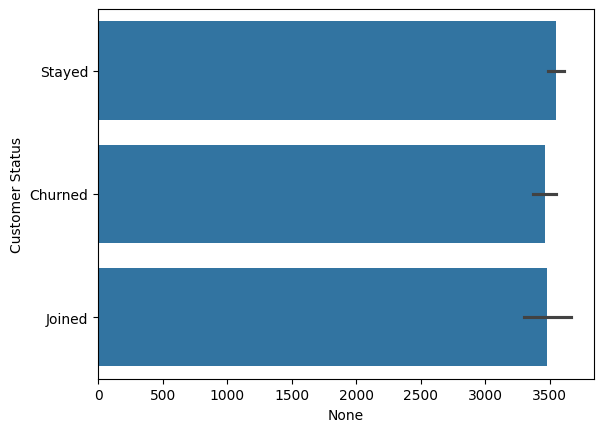

In [23]:
sns.barplot(x=df.index,y=df['Customer Status'])

In [24]:
df["Churn Reason"]

0                                 NaN
1                                 NaN
2       Competitor had better devices
3             Product dissatisfaction
4                 Network reliability
                    ...              
7038                              NaN
7039          Product dissatisfaction
7040                              NaN
7041                              NaN
7042                              NaN
Name: Churn Reason, Length: 7043, dtype: object

In [26]:
df['Churn Reason']=df["Churn Reason"].fillna(df["Churn Reason"].mode()[0])
df['Churn Reason'].head()

0    Competitor had better devices
1    Competitor had better devices
2    Competitor had better devices
3          Product dissatisfaction
4              Network reliability
Name: Churn Reason, dtype: object

In [28]:
df['Churn Reason'].count()

np.int64(7043)

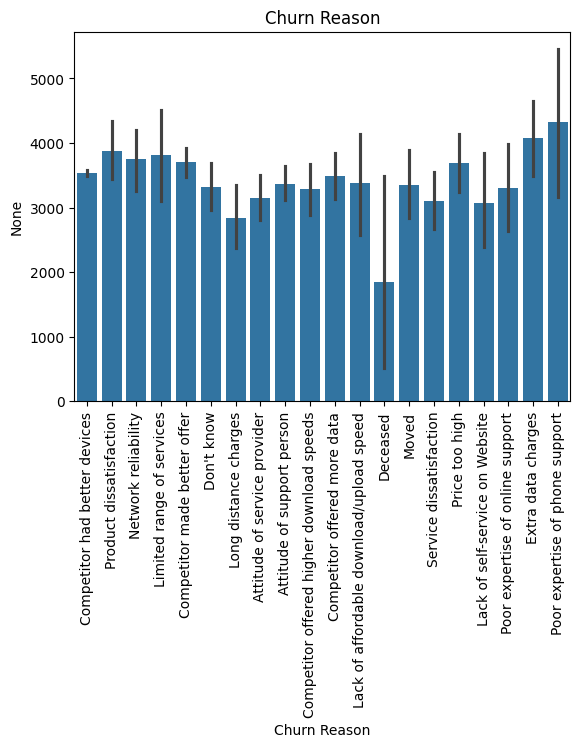

In [31]:
sns.barplot(x=df['Churn Reason'],y=df.index)
plt.xticks(rotation=90)
plt.title('Churn Reason')
plt.show()